In [83]:
import os
import re
import time
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


### Part A - Image Feature Extraction and Classification

In [84]:
IMAGE_ROOT = Path("xnzhj3x8v4-1")

print("Dataset exists:", IMAGE_ROOT.exists())
print("Dataset path:", IMAGE_ROOT.resolve())

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

image_paths = [
    p for p in IMAGE_ROOT.rglob("*")
    if p.suffix.lower() in image_extensions
]

print("Total images found:", len(image_paths))

for path in image_paths[:10]:
    print(path)


from collections import Counter

parent_folders = Counter([p.parent.name for p in image_paths])

print("Images by parent folder:")
for folder, count in parent_folders.items():
    print(folder, ":", count)

Dataset exists: True
Dataset path: C:\Users\daksh\OneDrive\Documents\DAU\SEM 1\Machine Learning\202618033_DS605\202618033_Lab_6\xnzhj3x8v4-1
Total images found: 400
xnzhj3x8v4-1\448\Cracks\IMG_20180513_164959951_HDR resized_448.jpg
xnzhj3x8v4-1\448\Cracks\IMG_20180513_165129852_HDR resized_448.jpg
xnzhj3x8v4-1\448\Cracks\IMG_20180513_165150613_HDR resized_448.jpg
xnzhj3x8v4-1\448\Cracks\IMG_20180513_165345878_HDR resized_448.jpg
xnzhj3x8v4-1\448\Cracks\IMG_20180513_165349788_HDR resized_448.jpg
xnzhj3x8v4-1\448\Cracks\IMG_20180513_165353081_HDR resized_448.jpg
xnzhj3x8v4-1\448\Cracks\IMG_20180513_165451567_HDR resized_448.jpg
xnzhj3x8v4-1\448\Cracks\IMG_20180513_165455803_HDR resized_448.jpg
xnzhj3x8v4-1\448\Cracks\IMG_20180513_165500303_HDR resized_448.jpg
xnzhj3x8v4-1\448\Cracks\IMG_20180513_165512488_HDR resized_448.jpg
Images by parent folder:
Cracks : 200
NonCracks : 200


In [85]:
def get_label_from_path(path):
    path_text = str(path).lower()

    if "non-crack" in path_text or "non_crack" in path_text or "noncrack" in path_text:
        return 0

    if "crack" in path_text:
        return 1

    return None


labels_test = []

for path in image_paths:
    label = get_label_from_path(path)
    labels_test.append(label)

print("Unrecognized images:", labels_test.count(None))
print("Crack images:", labels_test.count(1))
print("Non-crack images:", labels_test.count(0))

Unrecognized images: 0
Crack images: 200
Non-crack images: 200


In [86]:
image_info = []

for path in image_paths:
    img = cv2.imread(str(path))

    if img is None:
        continue

    height, width, channels = img.shape

    image_info.append({
        "filename": path.name,
        "width": width,
        "height": height,
        "channels": channels,
        "label": get_label_from_path(path)
    })

image_info_df = pd.DataFrame(image_info)

print(image_info_df)


print("Unique dimensions:")
print(
    image_info_df[["width", "height"]]
    .drop_duplicates()
    .head(20)
)

print("\nChannel distribution:")
print(image_info_df["channels"].value_counts())

                                       filename  width  height  channels  \
0    IMG_20180513_164959951_HDR resized_448.jpg    448     448         3   
1    IMG_20180513_165129852_HDR resized_448.jpg    448     448         3   
2    IMG_20180513_165150613_HDR resized_448.jpg    448     448         3   
3    IMG_20180513_165345878_HDR resized_448.jpg    448     448         3   
4    IMG_20180513_165349788_HDR resized_448.jpg    448     448         3   
..                                          ...    ...     ...       ...   
395                    IMG_8821 resized_448.jpg    448     448         3   
396                    IMG_8822 resized_448.jpg    448     448         3   
397                    IMG_8823 resized_448.jpg    448     448         3   
398                    IMG_8824 resized_448.jpg    448     448         3   
399                    IMG_8825 resized_448.jpg    448     448         3   

     label  
0        1  
1        1  
2        1  
3        1  
4        1  
..     ..

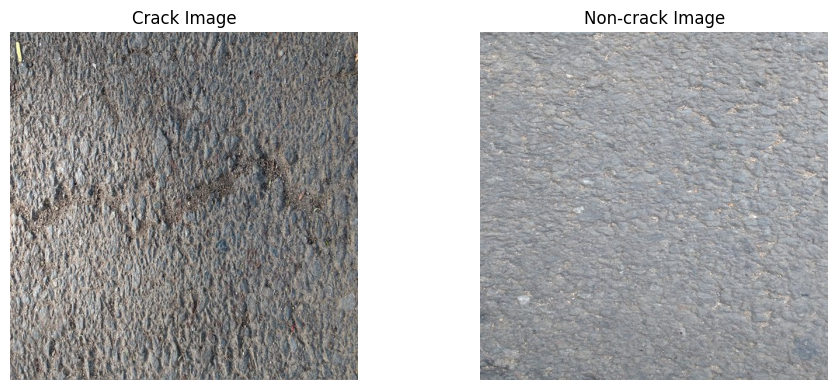

In [87]:
crack_path = next(p for p in image_paths if "crack" in p.parent.name.lower() and "non" not in p.parent.name.lower())
noncrack_path = next(p for p in image_paths if "non" in p.parent.name.lower())

crack_img = cv2.imread(str(crack_path))
noncrack_img = cv2.imread(str(noncrack_path))

crack_rgb = cv2.cvtColor(crack_img, cv2.COLOR_BGR2RGB)
noncrack_rgb = cv2.cvtColor(noncrack_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(crack_rgb)
plt.title("Crack Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(noncrack_rgb)
plt.title("Non-crack Image")
plt.axis("off")

plt.tight_layout()
plt.show()

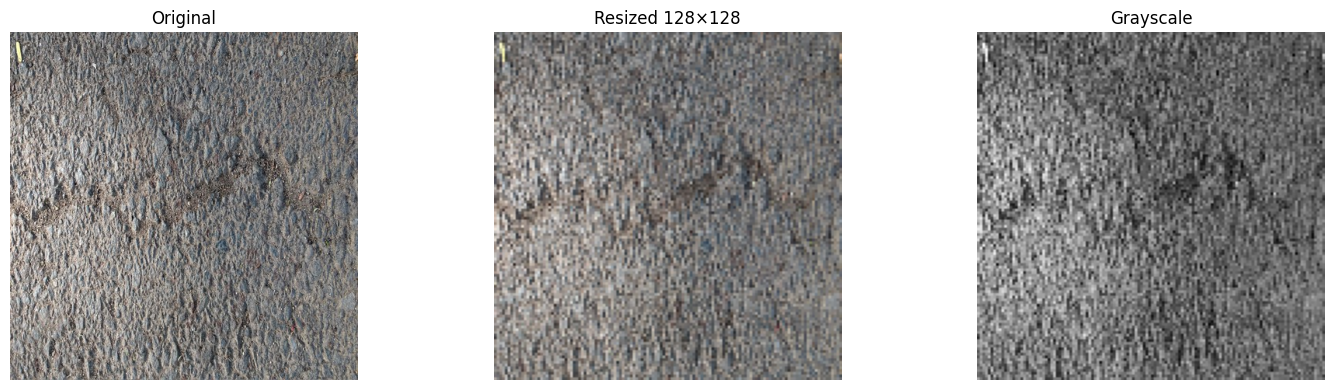

In [88]:
IMAGE_SIZE = (128, 128)

def preprocess_image(path):
    img = cv2.imread(str(path))

    if img is None:
        return None, None

    resized = cv2.resize(img, IMAGE_SIZE)

    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    return resized, gray


path = image_paths[0]

original = cv2.imread(str(path))
resized, gray = preprocess_image(path)

original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(original_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(resized_rgb)
plt.title("Resized 128×128")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.tight_layout()
plt.show()

In [89]:
def extract_image_features(gray):
    
    mean_brightness = np.mean(gray)
    std_intensity = np.std(gray)
    variance = np.var(gray)
    
    min_intensity = np.min(gray)
    max_intensity = np.max(gray)
    median_intensity = np.median(gray)
    
    percentile_25 = np.percentile(gray, 25)
    percentile_75 = np.percentile(gray, 75)
    
    intensity_range = max_intensity - min_intensity
    
    dark_pixel_ratio = np.mean(gray < 50)
    bright_pixel_ratio = np.mean(gray > 200)
    
    edges = cv2.Canny(gray, 100, 200)
    
    edge_count = np.count_nonzero(edges)
    
    total_pixels = gray.shape[0] * gray.shape[1]
    
    edge_density = edge_count / total_pixels
    
    return {
        "mean_brightness": mean_brightness,
        "std_intensity": std_intensity,
        "variance": variance,
        "min_intensity": min_intensity,
        "max_intensity": max_intensity,
        "median_intensity": median_intensity,
        "percentile_25": percentile_25,
        "percentile_75": percentile_75,
        "intensity_range": intensity_range,
        "dark_pixel_ratio": dark_pixel_ratio,
        "bright_pixel_ratio": bright_pixel_ratio,
        "edge_count": edge_count,
        "edge_density": edge_density
    }

In [90]:
feature_rows = []

for path in image_paths:
    
    label = get_label_from_path(path)
    
    if label is None:
        continue
    
    resized, gray = preprocess_image(path)
    
    if gray is None:
        continue
    
    features = extract_image_features(gray)
    
    features["filename"] = path.name
    features["label"] = label
    
    feature_rows.append(features)

image_features_df = pd.DataFrame(feature_rows)

print("Feature table shape:", image_features_df.shape)
image_features_df.head()

Feature table shape: (400, 15)


,mean_brightness,std_intensity,variance,min_intensity,max_intensity,median_intensity,percentile_25,percentile_75,intensity_range,dark_pixel_ratio,bright_pixel_ratio,edge_count,edge_density,filename,label
0,122.263977,33.070752,1093.674640,27,247,121.0,99.0,144.0,220,0.005859,0.014465,5580,0.340576,IMG_20180513_164959951_HDR resized_448.jpg,1
1,131.565186,25.482184,649.341698,13,252,133.0,116.0,148.0,239,0.003418,0.004456,4579,0.279480,IMG_20180513_165129852_HDR resized_448.jpg,1
2,121.076355,31.130490,969.107390,4,237,120.0,103.0,137.0,233,0.014221,0.010498,4303,0.262634,IMG_20180513_165150613_HDR resized_448.jpg,1
3,130.309143,27.282676,744.344433,8,251,131.0,112.0,149.0,243,0.002197,0.006592,5507,0.336121,IMG_20180513_165345878_HDR resized_448.jpg,1
4,130.993286,27.639562,763.945389,20,252,132.0,114.0,149.0,232,0.003357,0.007751,5218,0.318481,IMG_20180513_165349788_HDR resized_448.jpg,1


label
1    200
0    200
Name: count, dtype: int64

Class proportions:
label
1    0.5
0    0.5
Name: proportion, dtype: float64
Saved: outputs\image_features.csv


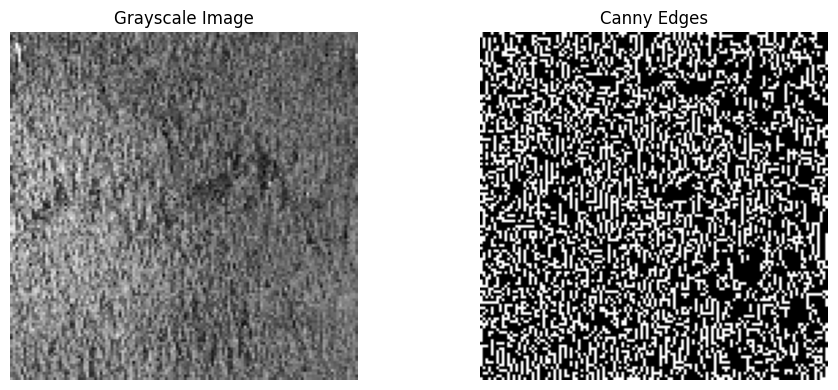

Canny visualizations saved.


In [91]:
print(image_features_df["label"].value_counts())

print("\nClass proportions:")
print(image_features_df["label"].value_counts(normalize=True))


OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

image_features_df.to_csv(
    OUTPUT_DIR / "image_features.csv",
    index=False
)

print("Saved:", OUTPUT_DIR / "image_features.csv")


path = image_paths[0]

_, gray = preprocess_image(path)

edges = cv2.Canny(gray, 100, 200)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.tight_layout()
plt.show()


canny_dir = OUTPUT_DIR / "canny_visualizations"
canny_dir.mkdir(exist_ok=True)

for i, path in enumerate(image_paths[:5]):
    
    _, gray = preprocess_image(path)
    edges = cv2.Canny(gray, 100, 200)
    
    save_path = canny_dir / f"canny_{i+1}.png"
    
    cv2.imwrite(str(save_path), edges)

print("Canny visualizations saved.")

In [92]:
feature_columns = [
    "mean_brightness",
    "contrast",         
    "variance",
    "min_intensity",
    "max_intensity",
    "median_intensity",
    "percentile_25",
    "percentile_75",
    "intensity_range",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "edge_count",
    "edge_density"
]

feature_columns = [col for col in feature_columns if col in image_features_df.columns]

X_image = image_features_df[feature_columns]
y_image = image_features_df["label"]

print("X shape:", X_image.shape)
print("y shape:", y_image.shape)

X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(
    X_image,
    y_image,
    test_size=0.20,
    random_state=42,
    stratify=y_image
)

print("Training samples:", len(X_train_img))
print("Testing samples:", len(X_test_img))

X shape: (400, 12)
y shape: (400,)
Training samples: 320
Testing samples: 80


In [93]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    
    # Training time
    start_train = time.perf_counter()
    model.fit(X_train, y_train)
    end_train = time.perf_counter()
    
    training_time = end_train - start_train
    
    # Prediction time
    start_pred = time.perf_counter()
    predictions = model.predict(X_test)
    end_pred = time.perf_counter()
    
    prediction_time = end_pred - start_pred
    
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1 Score": f1_score(y_test, predictions, zero_division=0),
        "Training Time (s)": training_time,
        "Prediction Time (s)": prediction_time
    }
    
    return model, predictions, results

In [94]:
image_models = [
    (
        "Logistic Regression",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000))
        ])
    ),
    
    (
        "Decision Tree",
        DecisionTreeClassifier(
            random_state=42,
            max_depth=5
        )
    ),
    
    (
        "Random Forest",
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )   
    )
]

In [95]:
image_results = []
trained_image_models = {}

for name, model in image_models:
    
    trained_model, predictions, result = evaluate_model(
        model,
        X_train_img,
        X_test_img,
        y_train_img,
        y_test_img,
        name
    )
    
    image_results.append(result)
    trained_image_models[name] = trained_model

image_results_df = pd.DataFrame(image_results)

image_results_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.950,0.950000,0.95,0.950000,0.019821,0.001935
1,Decision Tree,0.925,0.947368,0.90,0.923077,0.003805,0.001137
2,Random Forest,0.950,0.950000,0.95,0.950000,0.318935,0.018872


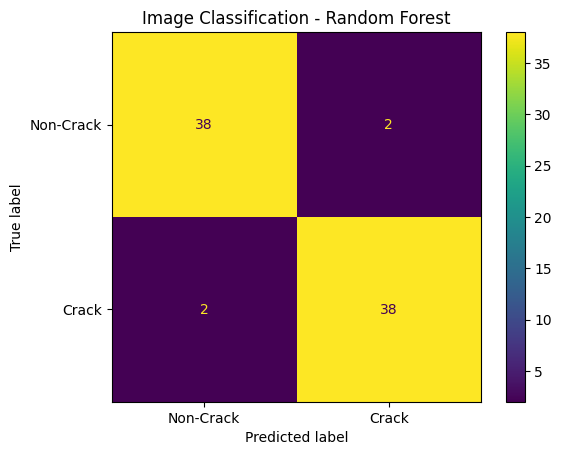

In [96]:
model = trained_image_models["Random Forest"]

predictions = model.predict(X_test_img)

cm = confusion_matrix(y_test_img, predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Crack", "Crack"]
)

disp.plot()
plt.title("Image Classification - Random Forest")
plt.show()

In [97]:
print(
    classification_report(
        y_test_img,
        predictions,
        target_names=["Non-Crack", "Crack"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

   Non-Crack       0.95      0.95      0.95        40
       Crack       0.95      0.95      0.95        40

    accuracy                           0.95        80
   macro avg       0.95      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80



### Part C - Improve the Representation

In [98]:
def extract_improved_features(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (224, 224))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Original Intensity Features
    mean_brightness = np.mean(gray)
    contrast = np.std(gray)
    min_intensity = np.min(gray)
    max_intensity = np.max(gray)
    median_intensity = np.median(gray)
    dark_pixel_ratio = np.sum(gray < 50) / gray.size
    bright_pixel_ratio = np.sum(gray > 200) / gray.size

    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150)

    edge_count = np.count_nonzero(edges)
    edge_density = edge_count / edges.size

    return [
        mean_brightness,
        contrast,
        min_intensity,
        max_intensity,
        median_intensity,
        dark_pixel_ratio,
        bright_pixel_ratio,
        edge_count,
        edge_density
    ]

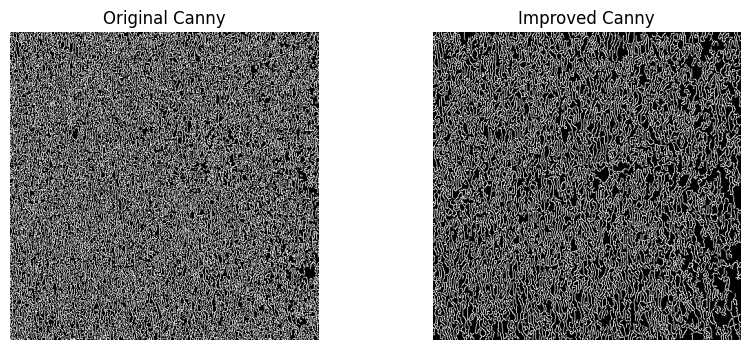

In [99]:
sample_crack_path = next(p for p in image_paths if "crack" in str(p).lower() and "non" not in str(p).lower())
crack_img = cv2.imread(str(sample_crack_path))
crack_gray = cv2.cvtColor(crack_img, cv2.COLOR_BGR2GRAY)

original_edges = cv2.Canny(crack_gray, 100, 200)

blurred_crack = cv2.GaussianBlur(crack_gray, (5, 5), 0)
improved_edges = cv2.Canny(blurred_crack, 50, 150)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_edges, cmap="gray")
plt.title("Original Canny")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(improved_edges, cmap="gray")
plt.title("Improved Canny")
plt.axis("off")

plt.show()

In [100]:
improved_data = []

for path in image_paths:
    label = get_label_from_path(path)
    
    if label is not None:
        features = extract_improved_features(str(path))
        improved_data.append([path.name] + features + [label])

improved_features_df = pd.DataFrame(
    improved_data,
)
print("Improved dataset shape: ", improved_features_df.shape)
improved_features_df.head()

Improved dataset shape:  (400, 11)


,0,1,2,3,4,5,6,7,8,9,10
0,IMG_20180513_164959951_HDR resized_448.jpg,122.224609,31.513482,23,247,121.0,0.003846,0.010922,10528,0.209821,1
1,IMG_20180513_165129852_HDR resized_448.jpg,131.948681,24.096114,8,251,133.0,0.002790,0.003787,6178,0.123127,1
2,IMG_20180513_165150613_HDR resized_448.jpg,121.297313,29.884272,2,241,121.0,0.013333,0.008171,7950,0.158442,1
3,IMG_20180513_165345878_HDR resized_448.jpg,130.245596,25.649018,20,253,131.0,0.001893,0.004006,9398,0.187301,1
4,IMG_20180513_165349788_HDR resized_448.jpg,131.208885,26.237598,11,254,132.0,0.002372,0.006258,8411,0.167630,1


In [101]:
X_improved = improved_features_df.iloc[:, 1:-1]

# 2. Grab ONLY the very last column (label)
y_improved = improved_features_df.iloc[:, -1]

#train test split
X_train_improved, X_test_improved, y_train_improved, y_test_improved = train_test_split(
    X_improved,
    y_improved,
    test_size=0.2,
    random_state=42,
    stratify=y_improved
)

# training random forest
improved_rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
start_train = time.time()
improved_rf_model.fit(
    X_train_improved,
    y_train_improved
)
end_train = time.time()
improved_rf_training_time = end_train - start_train

start_predict = time.time()
improved_rf_predictions = improved_rf_model.predict(
    X_test_improved
)
end_predict = time.time()
improved_rf_prediction_time = end_predict - start_predict

improved_rf_accuracy = accuracy_score(y_test_improved, improved_rf_predictions)
improved_rf_precision = precision_score(y_test_improved, improved_rf_predictions)
improved_rf_recall = recall_score(y_test_improved, improved_rf_predictions)
improved_rf_f1 = f1_score(y_test_improved, improved_rf_predictions)


print("Improved Random Forest Results: ")
print("Accuracy: ", improved_rf_accuracy)
print("Precision: ", improved_rf_precision)
print("Recall: ", improved_rf_recall)
print("F1-Score: ", improved_rf_f1)
print("Training time: ", improved_rf_training_time, "seconds")
print("Prediction time: ", improved_rf_prediction_time, "seconds")
print("\nConfusion Matrix")
print(confusion_matrix(y_test_improved, improved_rf_predictions))

Improved Random Forest Results: 
Accuracy:  0.95
Precision:  0.95
Recall:  0.95
F1-Score:  0.95
Training time:  0.13574767112731934 seconds
Prediction time:  0.0068511962890625 seconds

Confusion Matrix
[[38  2]
 [ 2 38]]


In [102]:
original_rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

start_train = time.time()
original_rf_model.fit(X_train_img, y_train_img)
rf_training_time = time.time() - start_train

start_predict = time.time()
rf_predictions = original_rf_model.predict(X_test_img)
rf_prediction_time = time.time() - start_predict

rf_accuracy = accuracy_score(y_test_img, rf_predictions)
rf_precision = precision_score(y_test_img, rf_predictions, zero_division=0)
rf_recall = recall_score(y_test_img, rf_predictions, zero_division=0)
rf_f1 = f1_score(y_test_img, rf_predictions, zero_division=0)

part_c_comparison = pd.DataFrame({
    "Approach": [
        "Original Random Forest",
        "Improved Random Forest"
    ],

    "Canny Method": [
        "Gray, thresholds 100-200",
        "Gaussian Blur, thresholds 50-150"
    ],

    "Number of Features": [
        X_train_img.shape[1],
        X_train_improved.shape[1]
    ],

    "Accuracy": [
        rf_accuracy,
        improved_rf_accuracy
    ],

    "Precision": [
        rf_precision,
        improved_rf_precision
    ],

    "Recall": [
        rf_recall,
        improved_rf_recall
    ],

    "F1-Score": [
        rf_f1,
        improved_rf_f1
    ],

    "Training Time (s)": [
        rf_training_time,
        improved_rf_training_time
    ],

    "Prediction Time (s)": [
        rf_prediction_time,
        improved_rf_prediction_time
    ]
})

part_c_comparison

,Approach,Canny Method,Number of Features,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Original Random Forest,"Gray, thresholds 100-200",12,0.95,0.95,0.95,0.95,0.170458,0.009017
1,Improved Random Forest,"Gaussian Blur, thresholds 50-150",9,0.95,0.95,0.95,0.95,0.135748,0.006851


### Part B - Text Vectorization and Spam Classification

In [103]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

emails_df = pd.read_csv("emails.csv")
print("Dataset shape: ", emails_df.shape)

print("\n Column Names: ")
print(emails_df.columns)
print("\nFirst 5 rows:")
emails_df.head()



Dataset shape:  (5172, 3002)

 Column Names: 
Index(['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou',
       ...
       'connevey', 'jay', 'valued', 'lay', 'infrastructure', 'military',
       'allowing', 'ff', 'dry', 'Prediction'],
      dtype='str', length=3002)

First 5 rows:


,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [104]:
print(emails_df["Prediction"].value_counts())
print("\nClass Distribution (%): ")
print(
    emails_df["Prediction"]
    .value_counts(normalize=True)
    .mul(100)
)

Prediction
0    3672
1    1500
Name: count, dtype: int64

Class Distribution (%): 
Prediction
0    70.99768
1    29.00232
Name: proportion, dtype: float64


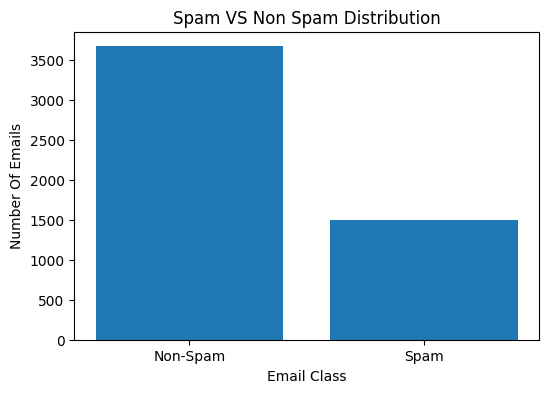

In [105]:
class_counts = emails_df["Prediction"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(
    ["Non-Spam", "Spam"],
    class_counts.values
)
plt.title("Spam VS Non Spam Distribution")
plt.xlabel("Email Class")
plt.ylabel("Number Of Emails")
plt.show()

In [106]:
word_columns = emails_df.columns.drop(["Email No.", "Prediction"])
print("Number of word columns: ", len(word_columns))
print("\nFirst 20 words: ")
print(word_columns[:20].tolist())

Number of word columns:  3000

First 20 words: 
['the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with']


In [107]:
def reconstruct_email(row):
    words = []
    for word in word_columns:
        count = int(row[word])

        if count > 0:
            words.extend([word] * count)
    return " ".join(words)

emails_df["reconstructed_text"] = emails_df.apply(
    reconstruct_email,
    axis=1
)

print(emails_df["reconstructed_text"].iloc[0][:500])

ect a a is i i s s s as re re e e e e t t t t j m m b p c c c r r r r f h u u tu st ic far chris hr rm tr pictures pi ma picture ct ct christmas ur tm


In [108]:
X_text = emails_df["reconstructed_text"]
y_text = emails_df["Prediction"]

print("Number of emails: ", len(X_text))
print("Number of labels: ", len(y_text))

Number of emails:  5172
Number of labels:  5172


In [109]:
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text,
    y_text,
    test_size=0.2,
    random_state=42,
    stratify=y_text

)

print("Training emails: ", len(X_train_text))
print("Testing emails: ", len(X_test_text))

print("\nTraining Distribution: ")
print(y_train_text.value_counts())

print("\nTesting Distribution: ")
print(y_test_text.value_counts())

Training emails:  4137
Testing emails:  1035

Training Distribution: 
Prediction
0    2937
1    1200
Name: count, dtype: int64

Testing Distribution: 
Prediction
0    735
1    300
Name: count, dtype: int64


In [110]:
count_vertorizer = CountVectorizer()

X_train_count = count_vertorizer.fit_transform(X_train_text)
X_test_count = count_vertorizer.transform(X_test_text)

print("Training matrix shape: ", X_train_count.shape)
print("Testing matrix shape: ", X_test_count.shape)

print("Number of features: ", len(count_vertorizer.get_feature_names_out()))

Training matrix shape:  (4137, 2974)
Testing matrix shape:  (1035, 2974)
Number of features:  2974


In [111]:
text_lr_model = LogisticRegression(max_iter=1000)
start_train = time.time()
text_lr_model.fit(X_train_count, y_train_text)
end_train = time.time()
text_lr_training_time = end_train - start_train

#Predict
start_predict = time.time()
text_lr_prediction = text_lr_model.predict(X_test_count)
end_predict = time.time()
text_lr_prediction_time = end_predict - start_predict

text_lr_accuracy = accuracy_score(y_test_text, text_lr_prediction)
text_lr_precision = precision_score(y_test_text, text_lr_prediction)
text_lr_recall = recall_score(y_test_text, text_lr_prediction)
text_lr_f1 = f1_score(y_test_text, text_lr_prediction)

print("Logistic Regression Results: ")
print("Accuracy: ", text_lr_accuracy)
print("Precision: ",text_lr_precision)
print("Recall: ", text_lr_recall)
print("F1-score: ", text_lr_f1)
print("Training time: ", text_lr_training_time, "seconds")
print("Prediction time: ", text_lr_prediction_time, "seconds")

print("\nConfusion Martix: ")
print(confusion_matrix(y_test_text, text_lr_prediction))

Logistic Regression Results: 
Accuracy:  0.9806763285024155
Precision:  0.9545454545454546
Recall:  0.98
F1-score:  0.9671052631578947
Training time:  0.950294017791748 seconds
Prediction time:  0.0010259151458740234 seconds

Confusion Martix: 
[[721  14]
 [  6 294]]


In [112]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
start_train = time.time()
nb_model.fit(X_train_count, y_train_text)
end_train = time.time()
nb_training_time = end_train - start_train

#predict
start_predict = time.time()
nb_prediction = nb_model.predict(X_test_count)
end_predict = time.time()
nb_prediction_time = end_predict - start_predict

nb_accuracy = accuracy_score(y_test_text, nb_prediction)
nb_precision = precision_score(y_test_text, nb_prediction)
nb_recall = recall_score(y_test_text, nb_prediction)
nb_f1 = f1_score(y_test_text, nb_prediction)

print("Multinomial Naive Bayes Results: ")
print("Accuracy: ", nb_accuracy)
print("Precision: ", nb_precision)
print("Recall: ", nb_recall)
print("F1-Score: ", nb_f1)
print("Training time: ", nb_training_time, "secomds")
print("Prediction time: ", nb_prediction_time, "seconds")
print("\nConfusion Martix: ")
print(confusion_matrix(y_test_text,nb_prediction))

Multinomial Naive Bayes Results: 
Accuracy:  0.9420289855072463
Precision:  0.8680981595092024
Recall:  0.9433333333333334
F1-Score:  0.9041533546325878
Training time:  0.011276006698608398 secomds
Prediction time:  0.0017430782318115234 seconds

Confusion Martix: 
[[692  43]
 [ 17 283]]


In [113]:
text_results_df = pd.DataFrame({
    "Model" : [
        "Logistic Regression",
        "Multinomial Naive Bayes"
    ],
    "Representation" : [
        "CountVectorizer",
        "CountVectorizer"
    ],
    "Number of Features" : [
        X_train_count.shape[1],
        X_train_count.shape[1]
    ],
    "Accuracy" : [
        text_lr_accuracy,
        nb_accuracy
    ],
    "Precision" : [
        text_lr_precision,
        nb_precision
    ],
    "Recall" : [
        text_lr_recall,
        nb_recall
    ],
    "F1-Score" : [
        text_lr_f1,
        nb_f1
    ],
    "Training time" : [
        text_lr_training_time,
        nb_training_time
    ],
    "Prediction time" : [
        text_lr_prediction_time,
        nb_prediction_time
    ]
})

text_results_df

,Model,Representation,Number of Features,Accuracy,Precision,Recall,F1-Score,Training time,Prediction time
0,Logistic Regression,CountVectorizer,2974,0.980676,0.954545,0.980000,0.967105,0.950294,0.001026
1,Multinomial Naive Bayes,CountVectorizer,2974,0.942029,0.868098,0.943333,0.904153,0.011276,0.001743


In [114]:
text_results_df.to_csv(
    "text_model_results.csv",
    index=False
)